# Apnea Detection Training

Supervised cloud AI training notebook for 1-minute sleep apnea detection using the local Mendeley APNEA HRV+SPO2 / HuGCDN2014-OXI dataset.

Important dataset note: `RR` contains ECG-derived R-R intervals, not respiratory rate. `SAT` contains oxygen saturation / SpO2 signal. `LABELS` contains apnea/non-apnea labels per minute.


## 1. Setup and Imports


In [1]:
import os
import re
import json
import math
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.stats import linregress
from scipy.io import loadmat, whosmat

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.neural_network import MLPClassifier

import joblib
from IPython.display import display

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

try:
    import xgboost as xgb
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
except Exception:
    HAS_LIGHTGBM = False

print("XGBoost available:", HAS_XGBOOST)
print("LightGBM available:", HAS_LIGHTGBM)


XGBoost available: True
LightGBM available: True


## 2. Configuration


In [2]:
BASE_DIR = Path(".")
RAW_DIR = BASE_DIR / "data" / "raw"
RR_DIR = RAW_DIR / "RR"
SAT_DIR = RAW_DIR / "SAT"
LABELS_DIR = RAW_DIR / "LABELS"

PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
REPORTS_DIR = BASE_DIR / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Base directory:", BASE_DIR.resolve())
print("Raw directory:", RAW_DIR.resolve())


Base directory: D:\Code\Informatika\Semester 8\IOT\model\edge ai\prediction\apnea detection
Raw directory: D:\Code\Informatika\Semester 8\IOT\model\edge ai\prediction\apnea detection\data\raw


## 3. Dataset Folder Inspection


In [3]:
required_folders = [RR_DIR, SAT_DIR, LABELS_DIR]

for folder in required_folders:
    if not folder.exists():
        raise FileNotFoundError(
            f"Required folder does not exist: {folder.resolve()}\n"
            "Run this notebook from edge ai/prediction/apnea detection/."
        )

for folder in [RR_DIR, SAT_DIR, LABELS_DIR]:
    print(folder)
    files = [p for p in folder.rglob("*") if p.is_file()]
    print("File count:", len(files))
    print("Extensions:", Counter([p.suffix.lower() for p in files]))
    print("Sample files:")
    for p in files[:10]:
        print(" -", p.name)
    print()

rr_files = sorted([p for p in RR_DIR.rglob("*") if p.is_file()])
sat_files = sorted([p for p in SAT_DIR.rglob("*") if p.is_file()])
label_files = sorted([p for p in LABELS_DIR.rglob("*") if p.is_file()])


data\raw\RR
File count: 83
Extensions: Counter({'.mat': 83})
Sample files:
 - C1.mat
 - C10.mat
 - C11.mat
 - C12.mat
 - C13.mat
 - C14.mat
 - C15.mat
 - C16.mat
 - C17.mat
 - C18.mat

data\raw\SAT
File count: 83
Extensions: Counter({'.mat': 83})
Sample files:
 - C1.mat
 - C10.mat
 - C11.mat
 - C12.mat
 - C13.mat
 - C14.mat
 - C15.mat
 - C16.mat
 - C17.mat
 - C18.mat

data\raw\LABELS
File count: 83
Extensions: Counter({'.mat': 83})
Sample files:
 - C1.mat
 - C10.mat
 - C11.mat
 - C12.mat
 - C13.mat
 - C14.mat
 - C15.mat
 - C16.mat
 - C17.mat
 - C18.mat



### Inspect `.mat` File Contents

This cell shows the actual MATLAB variables loaded from representative RR, SAT, and LABELS files. It also builds a small preview table from one record so you can see how the per-minute RR/SAT cells line up with `salida_man_1m` labels.


In [28]:

def _numeric_preview(values, max_values=6):
    arr = np.asarray(values).squeeze()
    if arr.size == 0:
        return np.array([], dtype=float)
    numeric = pd.to_numeric(pd.Series(arr.ravel()), errors="coerce").dropna()
    return numeric.to_numpy(dtype=float)[:max_values]


def _numeric_array(values):
    arr = np.asarray(values).squeeze()
    if arr.size == 0:
        return np.array([], dtype=float)
    numeric = pd.to_numeric(pd.Series(arr.ravel()), errors="coerce").dropna()
    return numeric.to_numpy(dtype=float)


def _format_first_values(values, max_values=6):
    preview = _numeric_preview(values, max_values=max_values)
    if preview.size == 0:
        return "[]"
    return np.array2string(preview, precision=3, separator=", ")


def inspect_mat_file(path: Path, max_cells=8):
    path = Path(path)
    print(f"\n--- {path.parent.name}/{path.name} ---")

    variable_rows = []
    for name, shape, dtype in whosmat(str(path)):
        variable_rows.append({
            "variable": name,
            "shape": shape,
            "mat_dtype": dtype,
        })
    display(pd.DataFrame(variable_rows))

    data = loadmat(str(path), squeeze_me=True, struct_as_record=False)
    public_vars = {k: v for k, v in data.items() if not k.startswith("__")}

    for variable_name, value in public_vars.items():
        arr = np.asarray(value)
        print(f"Variable preview: {variable_name}")

        if arr.dtype == object:
            rows = []
            for cell_index, item in enumerate(arr.ravel()[:max_cells]):
                numeric = _numeric_array(item)
                rows.append({
                    "cell_index": cell_index,
                    "cell_shape": np.asarray(item).shape,
                    "numeric_count": int(numeric.size),
                    "first_values": _format_first_values(item),
                    "min": float(np.nanmin(numeric)) if numeric.size else np.nan,
                    "max": float(np.nanmax(numeric)) if numeric.size else np.nan,
                })
            display(pd.DataFrame(rows))
        else:
            numeric = _numeric_array(arr)
            rows = [{
                "shape": arr.shape,
                "numeric_count": int(numeric.size),
                "first_values": _format_first_values(arr, max_values=12),
                "min": float(np.nanmin(numeric)) if numeric.size else np.nan,
                "max": float(np.nanmax(numeric)) if numeric.size else np.nan,
            }]
            display(pd.DataFrame(rows))

            if numeric.size:
                unique_values, counts = np.unique(numeric.astype(int), return_counts=True)
                unique_preview = pd.DataFrame({
                    "value": unique_values[:20],
                    "count": counts[:20],
                })
                print("Unique value preview:")
                display(unique_preview)


sample_rr_path = rr_files[0] if rr_files else None
if sample_rr_path is not None:
    sample_sat_path = SAT_DIR / sample_rr_path.name
    sample_label_path = LABELS_DIR / sample_rr_path.name

    for sample_path in [sample_rr_path, sample_sat_path, sample_label_path]:
        if sample_path.exists() and sample_path.suffix.lower() == ".mat":
            inspect_mat_file(sample_path)

    if sample_sat_path.exists() and sample_label_path.exists():
        print("\n--- Per-minute raw cell preview for one matched sample record ---")
        rr_data = loadmat(str(sample_rr_path), squeeze_me=True, struct_as_record=False)
        sat_data = loadmat(str(sample_sat_path), squeeze_me=True, struct_as_record=False)
        label_data = loadmat(str(sample_label_path), squeeze_me=True, struct_as_record=False)

        rr_cells = np.asarray(rr_data.get("RR_notch_abs_pr_ada", []), dtype=object).ravel()
        sat_cells = np.asarray(sat_data.get("SAT", []), dtype=object).ravel()
        labels_1m = np.asarray(label_data.get("salida_man_1m", []), dtype=float).ravel()

        preview_rows = []
        n_preview = min(12, max(len(rr_cells), len(sat_cells), len(labels_1m)))
        for minute_index in range(n_preview):
            rr_window = rr_cells[minute_index] if minute_index < len(rr_cells) else np.array([])
            sat_window = sat_cells[minute_index] if minute_index < len(sat_cells) else np.array([])
            rr_numeric = _numeric_array(rr_window)
            sat_numeric = _numeric_array(sat_window)
            preview_rows.append({
                "record_file": sample_rr_path.name,
                "minute_index": minute_index,
                "label_1m": int(labels_1m[minute_index]) if minute_index < len(labels_1m) else np.nan,
                "rr_count": int(rr_numeric.size),
                "rr_first_values": _format_first_values(rr_window),
                "rr_min": float(np.nanmin(rr_numeric)) if rr_numeric.size else np.nan,
                "rr_max": float(np.nanmax(rr_numeric)) if rr_numeric.size else np.nan,
                "spo2_count": int(sat_numeric.size),
                "spo2_first_values": _format_first_values(sat_window),
                "spo2_min": float(np.nanmin(sat_numeric)) if sat_numeric.size else np.nan,
                "spo2_max": float(np.nanmax(sat_numeric)) if sat_numeric.size else np.nan,
            })

        display(pd.DataFrame(preview_rows))
else:
    print("No RR files available for .mat content inspection.")



--- RR/C1.mat ---


,variable,shape,mat_dtype
0,RR_notch_abs_pr_ada,"(1, 316)",cell


Variable preview: RR_notch_abs_pr_ada


,cell_index,cell_shape,numeric_count,first_values,min,max
0,0,"(0,)",0,[],NaN,NaN
1,1,"(0,)",0,[],NaN,NaN
2,2,"(316,)",316,"[966.306, 956.843, 941.181, 938.19 , 935.743, ...",771.992625,1021.973963
3,3,"(318,)",318,"[942.357, 946.063, 946.933, 949.519, 950.936, ...",769.258779,1021.973963
4,4,"(319,)",319,"[989.794, 992.362, 989.065, 988.238, 978.722, ...",769.258779,1021.973963
5,5,"(317,)",317,"[951.406, 942.569, 943.881, 953.038, 957.953, ...",769.258779,1021.973963
6,6,"(319,)",319,"[968.05 , 954.286, 937.531, 909.666, 899.569, ...",769.258779,1007.818785
7,7,"(323,)",323,"[981.672, 974.312, 969.378, 975.792, 967.366, ...",769.258779,998.675039



--- SAT/C1.mat ---


...

,shape,numeric_count,first_values,min,max
0,"(317,)",317,"[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]",0.0,1.0


Unique value preview:


,value,count
0,0,309
1,1,8



--- Per-minute raw cell preview for one matched sample record ---


,record_file,minute_index,label_1m,rr_count,rr_first_values,rr_min,rr_max,spo2_count,spo2_first_values,spo2_min,spo2_max
0,C1.mat,0,0,0,[],NaN,NaN,0,[],NaN,NaN
1,C1.mat,1,0,0,[],NaN,NaN,0,[],NaN,NaN
2,C1.mat,2,0,316,"[966.306, 956.843, 941.181, 938.19 , 935.743, ...",771.992625,1021.973963,15000,"[96.999, 96.999, 96.999, 96.999, 96.999, 96.999]",94.988937,97.999542
3,C1.mat,3,0,318,"[942.357, 946.063, 946.933, 949.519, 950.936, ...",769.258779,1021.973963,15000,"[96.999, 96.999, 96.999, 96.999, 96.999, 96.999]",94.988937,97.999542
4,C1.mat,4,0,319,"[989.794, 992.362, 989.065, 988.238, 978.722, ...",769.258779,1021.973963,15000,"[96.999, 96.999, 96.999, 96.999, 96.999, 96.999]",94.988937,97.999542
5,C1.mat,5,0,317,"[951.406, 942.569, 943.881, 953.038, 957.953, ...",769.258779,1021.973963,15000,"[97.989, 97.989, 97.989, 97.989, 97.989, 97.989]",94.988937,97.999542
6,C1.mat,6,0,319,"[968.05 , 954.286, 937.531, 909.666, 899.569, ...",769.258779,1007.818785,15000,"[96.999, 96.999, 96.999, 96.999, 96.999, 96.999]",94.988937,97.999542
7,C1.mat,7,0,323,"[981.672, 974.312, 969.378, 975.792, 967.366, ...",769.258779,998.675039,15000,"[96.999, 96.999, 96.999, 96.999, 96.999, 96.989]",94.988937,97.999542
8,C1.mat,8,0,329,"[953.301, 953.128, 952.43 , 951.74 , 943.363, ...",778.308851,994.167135,15000,"[96.999, 96.999, 96.999, 96.999, 96.999, 96.999]",94.988937,97.999542
9,C1.mat,9,0,330,"[966.551, 971.465, 970.647, 966.26 , 979.399, ...",778.308851,999.163019,15000,"[96.999, 96.999, 96.999, 96.999, 96.999, 96.989]",94.988937,97.999542


## 4. File Matching by Record ID


In [4]:
def infer_record_id(path: Path) -> str:
    stem = path.stem
    stem = stem.replace("_RR", "").replace("_SAT", "").replace("_LABELS", "")
    stem = stem.replace("-RR", "").replace("-SAT", "").replace("-LABELS", "")
    stem = stem.replace("RR", "").replace("SAT", "").replace("LABELS", "")
    stem = re.sub(r"[^A-Za-z0-9]+", "", stem)
    return stem.lower()


def build_file_map(files):
    mapping = {}
    duplicates = defaultdict(list)
    for p in files:
        record_id = infer_record_id(p)
        if record_id in mapping:
            duplicates[record_id].append(p)
        else:
            mapping[record_id] = p
    if duplicates:
        print("Duplicate inferred IDs found. Keeping first file and listing duplicates:")
        for record_id, paths in duplicates.items():
            print(record_id, "duplicates:", [p.name for p in paths])
    return mapping


rr_map = build_file_map(rr_files)
sat_map = build_file_map(sat_files)
label_map = build_file_map(label_files)

common_ids = sorted(set(rr_map) & set(sat_map) & set(label_map))
unmatched_rr = sorted(set(rr_map) - set(common_ids))
unmatched_sat = sorted(set(sat_map) - set(common_ids))
unmatched_labels = sorted(set(label_map) - set(common_ids))

print("Number of RR files:", len(rr_files))
print("Number of SAT files:", len(sat_files))
print("Number of LABELS files:", len(label_files))
print("Number of matched records:", len(common_ids))
print("Unmatched RR IDs:", unmatched_rr[:20], "..." if len(unmatched_rr) > 20 else "")
print("Unmatched SAT IDs:", unmatched_sat[:20], "..." if len(unmatched_sat) > 20 else "")
print("Unmatched LABEL IDs:", unmatched_labels[:20], "..." if len(unmatched_labels) > 20 else "")

if not common_ids:
    raise RuntimeError(
        "No matched records found. Inspect filenames and adjust infer_record_id(path)."
    )

print("Sample matched IDs:", common_ids[:20])


Number of RR files: 83
Number of SAT files: 83
Number of LABELS files: 83
Number of matched records: 83
Unmatched RR IDs: [] 
Unmatched SAT IDs: [] 
Unmatched LABEL IDs: [] 
Sample matched IDs: ['c1', 'c10', 'c11', 'c12', 'c13', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c2', 'c20', 'c21', 'c22', 'c23', 'c24', 'c25', 'c26', 'c27']


If automatic matching fails on a different copy of the dataset, adjust `infer_record_id` above. The local dataset used here matches cleanly by filename stem after normalization.


In [5]:
# Manual matching hook for unusual dataset copies:
# def infer_record_id(path: Path) -> str:
#     stem = path.stem.lower()
#     # Add custom filename cleanup rules here.
#     return stem


## 5. Data Loading Utilities


In [6]:
DEFAULT_MAT_VARIABLE_PRIORITY = [
    "salida_man_1m",
    "RR_notch_abs_pr_ada",
    "SAT",
    "salida_man",
]


def preview_file(path: Path, n_lines=5):
    path = Path(path)
    print("Preview:", path)
    if path.suffix.lower() == ".mat":
        try:
            print("MAT variables:", whosmat(str(path)))
        except Exception as exc:
            print("Could not inspect MAT file:", exc)
        return

    with open(path, "r", errors="replace") as f:
        for i, line in enumerate(f):
            if i >= n_lines:
                break
            print(line.rstrip())


def load_mat_variable(path: Path, preferred_names=None):
    path = Path(path)
    preferred_names = preferred_names or DEFAULT_MAT_VARIABLE_PRIORITY
    data = loadmat(str(path), squeeze_me=True, struct_as_record=False)
    public = {k: v for k, v in data.items() if not k.startswith("__")}

    for name in preferred_names:
        if name in public:
            return name, public[name]

    for name, value in public.items():
        arr = np.asarray(value)
        if arr.size > 0:
            return name, value

    raise ValueError(f"No usable variables found in MAT file: {path}")


def as_numeric_1d(value) -> np.ndarray:
    if value is None:
        return np.array([], dtype=float)

    if isinstance(value, np.ndarray) and value.dtype == object:
        parts = []
        for item in value.ravel():
            item_arr = as_numeric_1d(item)
            if item_arr.size:
                parts.append(item_arr)
        if not parts:
            return np.array([], dtype=float)
        return np.concatenate(parts).astype(float)

    arr = np.asarray(value).squeeze()
    if arr.size == 0:
        return np.array([], dtype=float)

    numeric = pd.to_numeric(pd.Series(arr.ravel()), errors="coerce")
    numeric = numeric.dropna().astype(float)
    return numeric.to_numpy()


def load_mat_cells(path: Path, preferred_names=None):
    variable_name, value = load_mat_variable(path, preferred_names=preferred_names)
    arr = np.asarray(value)

    if arr.dtype == object:
        cells = [as_numeric_1d(item) for item in arr.ravel()]
        return variable_name, cells

    return variable_name, None


def load_numeric_file(path: Path) -> np.ndarray:
    '''
    Load numeric data from txt/csv/dat-like files or MATLAB .mat files.
    Try CSV comma, semicolon, tab, and whitespace-separated formats.
    Return a flattened numeric numpy array.
    '''
    path = Path(path)

    if path.suffix.lower() == ".mat":
        try:
            variable_name, value = load_mat_variable(path)
            arr = as_numeric_1d(value)
            if arr.size == 0:
                raise ValueError(f"Variable {variable_name} contains no numeric values.")
            return arr
        except Exception as exc:
            preview_file(path)
            raise ValueError(f"Failed to parse MAT numeric file {path}: {exc}") from exc

    parse_errors = []
    read_attempts = [
        {"sep": None, "engine": "python"},
        {"sep": ",", "engine": "python"},
        {"sep": ";", "engine": "python"},
        {"sep": "\t", "engine": "python"},
        {"sep": r"\s+", "engine": "python"},
    ]

    for kwargs in read_attempts:
        try:
            df = pd.read_csv(path, header=None, **kwargs)
            values = pd.to_numeric(df.stack(), errors="coerce").dropna().to_numpy(dtype=float)
            if values.size:
                return values.ravel()
        except Exception as exc:
            parse_errors.append(str(exc))

    try:
        values = np.loadtxt(path)
        values = pd.to_numeric(pd.Series(np.asarray(values).ravel()), errors="coerce").dropna()
        if len(values):
            return values.to_numpy(dtype=float)
    except Exception as exc:
        parse_errors.append(str(exc))

    preview_file(path)
    raise ValueError(
        f"Failed to parse numeric file {path}. Parser errors: {parse_errors[:3]}"
    )


## 6. RR Interval Processing


In [7]:
MIN_RR_MS = 300
MAX_RR_MS = 2000


def normalize_rr_intervals(rr_values: np.ndarray) -> np.ndarray:
    '''
    Return RR intervals in milliseconds.
    '''
    rr = as_numeric_1d(rr_values).astype(float)
    rr = rr[np.isfinite(rr)]
    if rr.size == 0:
        return rr

    median_rr = float(np.nanmedian(rr))
    original_summary = {
        "count": int(rr.size),
        "median": median_rr,
        "min": float(np.nanmin(rr)),
        "max": float(np.nanmax(rr)),
    }

    if median_rr < 3:
        rr_ms = rr * 1000.0
    elif 300 <= median_rr <= 2000:
        rr_ms = rr
    elif 3 <= median_rr < 300:
        warnings.warn(
            f"RR median is unusual ({median_rr:.3f}). Assuming seconds-like units and multiplying by 1000. Summary: {original_summary}"
        )
        rr_ms = rr * 1000.0
    elif 300000 <= median_rr <= 2000000:
        warnings.warn(
            f"RR median suggests microseconds. Dividing by 1000. Summary: {original_summary}"
        )
        rr_ms = rr / 1000.0
    else:
        warnings.warn(
            f"RR values are outside expected ranges. Keeping original units as ms before plausibility filtering. Summary: {original_summary}"
        )
        rr_ms = rr

    rr_ms = rr_ms[(rr_ms >= MIN_RR_MS) & (rr_ms <= MAX_RR_MS)]
    return rr_ms


def extract_rr_features(rr_ms_window: np.ndarray) -> dict:
    rr_ms = normalize_rr_intervals(rr_ms_window)
    rr_count = int(rr_ms.size)

    feature_names = [
        "rr_interval_mean",
        "rr_interval_std",
        "rr_interval_min",
        "rr_interval_max",
        "heart_rate_mean",
        "heart_rate_std",
        "heart_rate_min",
        "heart_rate_max",
        "heart_rate_slope",
        "sdnn",
        "rmssd",
        "pnn50",
    ]

    if rr_count < 3:
        features = {name: np.nan for name in feature_names}
        features["rr_count"] = rr_count
        return features

    heart_rate = 60000.0 / rr_ms
    rr_diff = np.diff(rr_ms)

    try:
        heart_rate_slope = float(linregress(np.arange(heart_rate.size), heart_rate).slope)
    except Exception:
        heart_rate_slope = np.nan

    features = {
        "rr_interval_mean": float(np.mean(rr_ms)),
        "rr_interval_std": float(np.std(rr_ms, ddof=1)),
        "rr_interval_min": float(np.min(rr_ms)),
        "rr_interval_max": float(np.max(rr_ms)),
        "heart_rate_mean": float(np.mean(heart_rate)),
        "heart_rate_std": float(np.std(heart_rate, ddof=1)),
        "heart_rate_min": float(np.min(heart_rate)),
        "heart_rate_max": float(np.max(heart_rate)),
        "heart_rate_slope": heart_rate_slope,
        "sdnn": float(np.std(rr_ms, ddof=1)),
        "rmssd": float(np.sqrt(np.mean(rr_diff ** 2))) if rr_diff.size else np.nan,
        "pnn50": float(np.mean(np.abs(rr_diff) > 50.0) * 100.0) if rr_diff.size else np.nan,
        "rr_count": rr_count,
    }
    return features


## 7. SAT / SpO2 Processing


In [8]:
def normalize_spo2_values(spo2_values: np.ndarray) -> np.ndarray:
    spo2 = as_numeric_1d(spo2_values).astype(float)
    spo2 = spo2[np.isfinite(spo2)]
    if spo2.size == 0:
        return spo2

    if np.nanmax(spo2) <= 1.2:
        spo2 = spo2 * 100.0

    spo2 = spo2[(spo2 >= 50.0) & (spo2 <= 100.0)]
    return spo2


def split_spo2_by_label_windows(spo2_values: np.ndarray, n_labels: int) -> list[np.ndarray]:
    spo2 = normalize_spo2_values(spo2_values)
    if n_labels <= 0:
        return []

    if spo2.size == 0:
        return [np.array([], dtype=float) for _ in range(n_labels)]

    expected_50hz = n_labels * 60 * 50
    expected_1hz = n_labels * 60

    if abs(spo2.size - expected_50hz) / max(expected_50hz, 1) < 0.10:
        print(f"SAT length {spo2.size} is close to {n_labels} minutes at 50 Hz.")
    elif abs(spo2.size - expected_1hz) / max(expected_1hz, 1) < 0.10:
        print(f"SAT length {spo2.size} is close to {n_labels} minutes at 1 Hz.")
    else:
        warnings.warn(
            f"SAT length {spo2.size} does not match expected 1 Hz or 50 Hz lengths for {n_labels} labels. Splitting into equal chunks."
        )

    return [chunk.astype(float) for chunk in np.array_split(spo2, n_labels)]


def count_desaturations(spo2: np.ndarray, drop_threshold=3.0, recovery_margin=1.0) -> int:
    if spo2.size < 3:
        return 0

    recent_max = float(spo2[0])
    in_event = False
    count = 0

    for value in spo2[1:]:
        value = float(value)
        if value > recent_max:
            recent_max = value
            in_event = False

        if (recent_max - value) >= drop_threshold and not in_event:
            count += 1
            in_event = True

        if in_event and value >= (recent_max - recovery_margin):
            in_event = False
            recent_max = value

    return int(count)


def extract_spo2_features(spo2_window: np.ndarray) -> dict:
    spo2 = normalize_spo2_values(spo2_window)
    spo2_count = int(spo2.size)

    feature_names = [
        "spo2_mean",
        "spo2_std",
        "spo2_min",
        "spo2_max",
        "spo2_slope",
        "spo2_drop",
        "spo2_desaturation_count",
        "spo2_time_below_90",
        "spo2_time_below_92",
    ]

    if spo2_count < 3:
        features = {name: np.nan for name in feature_names}
        features["spo2_count"] = spo2_count
        return features

    try:
        spo2_slope = float(linregress(np.arange(spo2.size), spo2).slope)
    except Exception:
        spo2_slope = np.nan

    features = {
        "spo2_mean": float(np.mean(spo2)),
        "spo2_std": float(np.std(spo2, ddof=1)),
        "spo2_min": float(np.min(spo2)),
        "spo2_max": float(np.max(spo2)),
        "spo2_slope": spo2_slope,
        "spo2_drop": float(np.max(spo2) - np.min(spo2)),
        "spo2_desaturation_count": count_desaturations(spo2),
        # Percent of samples in the 1-minute window below threshold.
        "spo2_time_below_90": float(np.mean(spo2 < 90.0) * 100.0),
        "spo2_time_below_92": float(np.mean(spo2 < 92.0) * 100.0),
        "spo2_count": spo2_count,
    }
    return features


## 8. Label Processing


In [9]:
def load_labels(path: Path) -> np.ndarray:
    if Path(path).suffix.lower() == ".mat":
        variable_name, value = load_mat_variable(path, preferred_names=["salida_man_1m", "salida_man"])
        labels = as_numeric_1d(value).astype(int)
        return labels

    raw = load_numeric_file(path)
    labels = raw.astype(int)
    return labels


for record_id in common_ids[:5]:
    labels = load_labels(label_map[record_id])
    print(record_id, np.unique(labels, return_counts=True))


def normalize_labels(labels: np.ndarray) -> np.ndarray:
    '''
    Return binary labels:
    0 = non-apnea
    1 = apnea
    '''
    labels = np.asarray(labels).astype(int).ravel()
    unique_values = sorted(np.unique(labels).tolist())
    value_set = set(unique_values)

    if value_set <= {0, 1}:
        return labels.astype(int)

    if value_set <= {-1, 1}:
        warnings.warn("Mapping labels {-1, 1} to {0, 1}: -1 -> 0, 1 -> 1.")
        return np.where(labels == 1, 1, 0).astype(int)

    if value_set <= {1, 2}:
        warnings.warn("Mapping labels {1, 2} to {0, 1}: 1 -> 0, 2 -> 1.")
        return np.where(labels == 2, 1, 0).astype(int)

    raise ValueError(
        f"Unknown label encoding {unique_values}. Expected 0/1, -1/1, or 1/2."
    )


c1 (array([0, 1]), array([309,   8], dtype=int64))
c10 (array([0, 1]), array([443,  10], dtype=int64))
c11 (array([0, 1]), array([419,   2], dtype=int64))
c12 (array([0, 1]), array([431,  15], dtype=int64))
c13 (array([0, 1]), array([454,   3], dtype=int64))


## 9. 1-Minute Feature Extraction


In [10]:
MISMATCH_LOGS = []


def load_rr_windows_or_flat(path: Path):
    if Path(path).suffix.lower() == ".mat":
        _, cells = load_mat_cells(path, preferred_names=["RR_notch_abs_pr_ada"])
        if cells is not None:
            return cells, None
    return None, load_numeric_file(path)


def load_spo2_windows_or_flat(path: Path):
    if Path(path).suffix.lower() == ".mat":
        _, cells = load_mat_cells(path, preferred_names=["SAT"])
        if cells is not None:
            return cells, None
    return None, load_numeric_file(path)


def split_rr_by_label_windows(rr_values: np.ndarray, n_labels: int) -> list[np.ndarray]:
    rr_ms = normalize_rr_intervals(rr_values)
    if n_labels <= 0:
        return []

    if rr_ms.size == 0:
        return [np.array([], dtype=float) for _ in range(n_labels)]

    rr_times_sec = np.cumsum(rr_ms) / 1000.0
    minute_idx = (rr_times_sec // 60).astype(int)
    valid = minute_idx < n_labels
    rr_ms = rr_ms[valid]
    minute_idx = minute_idx[valid]
    return [rr_ms[minute_idx == minute] for minute in range(n_labels)]


def extract_features_for_record(record_id, rr_path, sat_path, label_path) -> pd.DataFrame:
    labels = normalize_labels(load_labels(label_path))
    n_labels = int(labels.size)

    rr_cells, rr_flat = load_rr_windows_or_flat(rr_path)
    sat_cells, sat_flat = load_spo2_windows_or_flat(sat_path)

    if rr_cells is not None:
        rr_windows = rr_cells
        rr_source = "mat_cells"
    else:
        rr_windows = split_rr_by_label_windows(rr_flat, n_labels)
        rr_source = "flat_stream"

    if sat_cells is not None:
        sat_windows = sat_cells
        sat_source = "mat_cells"
    else:
        sat_windows = split_spo2_by_label_windows(sat_flat, n_labels)
        sat_source = "flat_stream"

    mismatch = {
        "record_id": record_id,
        "n_labels": n_labels,
        "n_rr_windows": len(rr_windows),
        "n_sat_windows": len(sat_windows),
        "rr_source": rr_source,
        "sat_source": sat_source,
    }
    if len(rr_windows) != n_labels or len(sat_windows) != n_labels:
        MISMATCH_LOGS.append(mismatch)

    rows = []
    for minute in range(n_labels):
        rr_window = rr_windows[minute] if minute < len(rr_windows) else np.array([], dtype=float)
        sat_window = sat_windows[minute] if minute < len(sat_windows) else np.array([], dtype=float)

        rr_features = extract_rr_features(rr_window)
        spo2_features = extract_spo2_features(sat_window)
        row = {}
        row.update(rr_features)
        row.update(spo2_features)

        hr_mean = row.get("heart_rate_mean", np.nan)
        spo2_mean = row.get("spo2_mean", np.nan)
        row["hr_spo2_ratio"] = float(hr_mean / spo2_mean) if np.isfinite(hr_mean) and np.isfinite(spo2_mean) and spo2_mean != 0 else np.nan
        row["hr_spo2_product"] = float(hr_mean * spo2_mean) if np.isfinite(hr_mean) and np.isfinite(spo2_mean) else np.nan

        row["label"] = int(labels[minute])
        row["record_id"] = record_id
        row["minute_index"] = int(minute)
        rows.append(row)

    return pd.DataFrame(rows)


## 10. Build Feature Dataset


In [11]:
record_dfs = []
errors = []
MISMATCH_LOGS = []

for record_id in common_ids:
    try:
        df_rec = extract_features_for_record(
            record_id,
            rr_map[record_id],
            sat_map[record_id],
            label_map[record_id],
        )
        record_dfs.append(df_rec)
    except Exception as e:
        errors.append({"record_id": record_id, "error": str(e)})

if not record_dfs:
    raise RuntimeError(f"No records could be processed. Errors: {errors[:5]}")

features_df = pd.concat(record_dfs, ignore_index=True)
features_path = PROCESSED_DIR / "apnea_features_1min.csv"
features_df.to_csv(features_path, index=False)

print("Saved:", features_path)
print("Shape:", features_df.shape)
print("Columns:", features_df.columns.tolist())
print("\nLabel distribution:")
print(features_df["label"].value_counts(dropna=False).sort_index())
print("\nMissing values:")
print(features_df.isna().sum().sort_values(ascending=False).head(30))
print("\nNumber of records:", features_df["record_id"].nunique())
print("\nRows per record:")
print(features_df.groupby("record_id").size().describe())

mismatch_df = pd.DataFrame(MISMATCH_LOGS)
if not mismatch_df.empty:
    print("\nMismatch summary:")
    display(mismatch_df.head(20))
else:
    print("\nNo RR/SAT/label window count mismatches found.")

if errors:
    print("\nProcessing errors:")
    display(pd.DataFrame(errors))

display(features_df.head())


Saved: data\processed\apnea_features_1min.csv
Shape: (34003, 28)
Columns: ['rr_interval_mean', 'rr_interval_std', 'rr_interval_min', 'rr_interval_max', 'heart_rate_mean', 'heart_rate_std', 'heart_rate_min', 'heart_rate_max', 'heart_rate_slope', 'sdnn', 'rmssd', 'pnn50', 'rr_count', 'spo2_mean', 'spo2_std', 'spo2_min', 'spo2_max', 'spo2_slope', 'spo2_drop', 'spo2_desaturation_count', 'spo2_time_below_90', 'spo2_time_below_92', 'spo2_count', 'hr_spo2_ratio', 'hr_spo2_product', 'label', 'record_id', 'minute_index']

Label distribution:
label
0    26157
1     7846
Name: count, dtype: int64

Missing values:
rr_interval_mean           636
spo2_mean                  636
hr_spo2_product            636
hr_spo2_ratio              636
spo2_time_below_92         636
spo2_time_below_90         636
spo2_desaturation_count    636
spo2_drop                  636
spo2_slope                 636
spo2_max                   636
spo2_min                   636
rr_interval_std            636
spo2_std          

,record_id,n_labels,n_rr_windows,n_sat_windows,rr_source,sat_source
0,c1,317,316,316,mat_cells,mat_cells
1,c10,453,452,452,mat_cells,mat_cells
2,c11,421,420,420,mat_cells,mat_cells
3,c13,457,456,456,mat_cells,mat_cells
4,c14,448,447,447,mat_cells,mat_cells
5,c17,471,470,470,mat_cells,mat_cells
6,c19,445,444,444,mat_cells,mat_cells
7,c21,452,451,451,mat_cells,mat_cells
8,c24,449,448,448,mat_cells,mat_cells
9,c25,443,442,442,mat_cells,mat_cells


,rr_interval_mean,rr_interval_std,rr_interval_min,rr_interval_max,heart_rate_mean,heart_rate_std,heart_rate_min,heart_rate_max,heart_rate_slope,sdnn,...,spo2_drop,spo2_desaturation_count,spo2_time_below_90,spo2_time_below_92,spo2_count,hr_spo2_ratio,hr_spo2_product,label,record_id,minute_index
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,c1,0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0,c1,1
2,945.365697,40.567858,771.992625,1021.973963,63.596153,3.015090,58.709911,77.72095,-0.000140,40.567858,...,3.010605,0.0,0.0,0.0,15000,0.655780,6167.422041,0,c1,2
3,940.182480,49.584571,769.258779,1021.973963,64.012520,3.720481,58.709911,77.99716,0.003170,49.584571,...,3.010605,1.0,0.0,0.0,15000,0.659620,6212.065011,0,c1,3
4,937.640216,48.685743,769.258779,1021.973963,64.179399,3.660093,58.709911,77.99716,-0.006344,48.685743,...,3.010605,1.0,0.0,0.0,15000,0.661116,6230.370534,0,c1,4


## 11. Exploratory Data Analysis


In [12]:
print("Dataset shape:", features_df.shape)
print("\nLabel distribution:")
label_counts = features_df["label"].value_counts().sort_index()
print(label_counts)
print("\nLabel distribution (%):")
print((label_counts / label_counts.sum() * 100).round(2))
print("\nMissing values:")
display(features_df.isna().sum().sort_values(ascending=False).to_frame("missing_count").head(30))
print("\nDescriptive statistics:")
display(features_df.describe().T)
print("\nPer-record window counts:")
display(features_df.groupby("record_id").size().describe().to_frame("windows_per_record"))


Dataset shape: (34003, 28)

Label distribution:
label
0    26157
1     7846
Name: count, dtype: int64

Label distribution (%):
label
0    76.93
1    23.07
Name: count, dtype: float64

Missing values:


,missing_count
rr_interval_mean,636
spo2_mean,636
hr_spo2_product,636
hr_spo2_ratio,636
spo2_time_below_92,636
spo2_time_below_90,636
spo2_desaturation_count,636
spo2_drop,636
spo2_slope,636
spo2_max,636



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
rr_interval_mean,33367.0,8.952745e+02,128.997277,5.853984e+02,806.257682,893.410272,984.692467,1321.869878
rr_interval_std,33367.0,5.130478e+01,28.462570,7.055782e+00,29.763363,45.481283,66.560738,214.173169
rr_interval_min,33367.0,7.572914e+02,122.307498,4.399047e+02,667.400091,744.914951,838.893892,1229.379616
rr_interval_max,33367.0,1.026336e+03,158.296558,6.141452e+02,920.794441,1027.002965,1126.689300,1784.212418
heart_rate_mean,33367.0,6.875177e+01,10.173571,4.545713e+01,61.198425,67.470254,74.758634,102.593047
heart_rate_std,33367.0,4.062250e+00,2.262515,4.939346e-01,2.307472,3.582555,5.412411,18.592982
heart_rate_min,33367.0,5.991043e+01,9.617966,3.362828e+01,53.253368,58.422421,65.161123,97.696766
heart_rate_max,33367.0,8.128115e+01,12.959806,4.880510e+01,71.522752,80.546108,89.901097,136.393181
heart_rate_slope,33367.0,-2.599567e-04,0.013412,-1.296751e-01,-0.005313,-0.000322,0.004458,0.127802
sdnn,33367.0,5.130478e+01,28.462570,7.055782e+00,29.763363,45.481283,66.560738,214.173169



Per-record window counts:


,windows_per_record
count,83.000000
mean,409.674699
std,77.003977
min,198.000000
25%,420.500000
50%,445.000000
75%,453.000000
max,475.000000


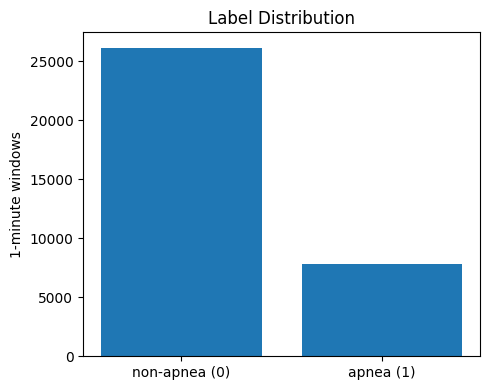

In [13]:
plt.figure(figsize=(5, 4))
plt.bar(["non-apnea (0)", "apnea (1)"], [label_counts.get(0, 0), label_counts.get(1, 0)])
plt.title("Label Distribution")
plt.ylabel("1-minute windows")
plt.tight_layout()
plt.show()


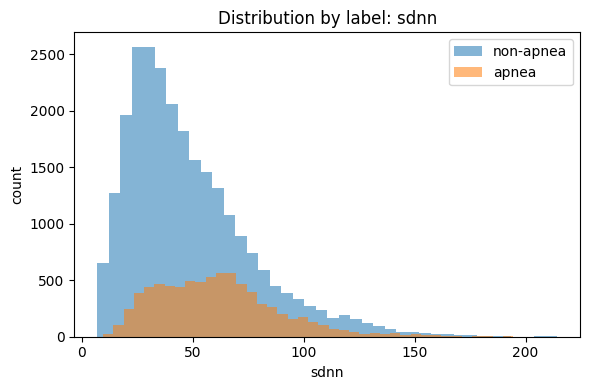

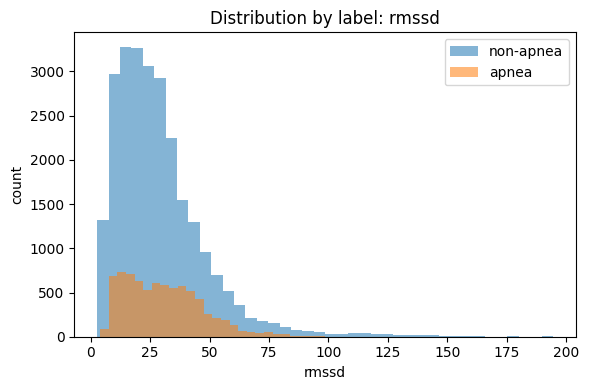

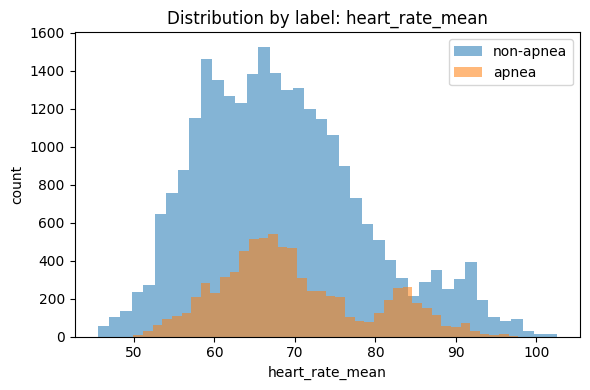

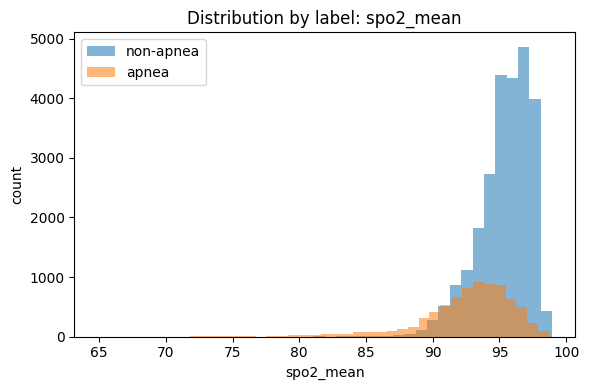

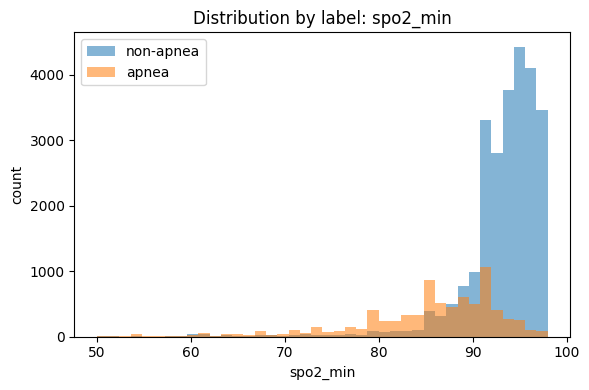

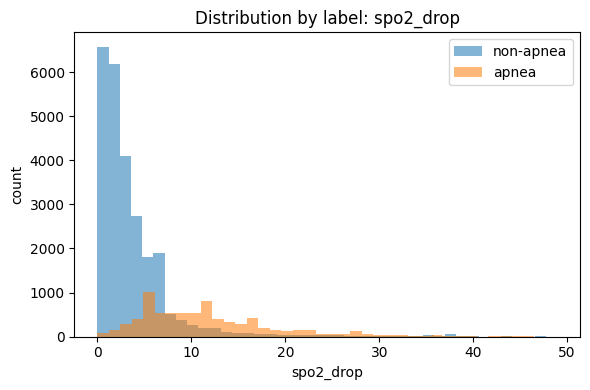

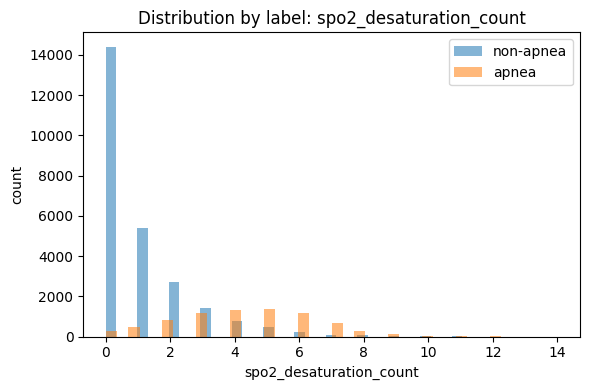

In [14]:
eda_feature_cols = [
    col for col in features_df.columns
    if col not in ["record_id", "minute_index", "label"]
    and pd.api.types.is_numeric_dtype(features_df[col])
]

key_features = [
    "sdnn",
    "rmssd",
    "heart_rate_mean",
    "spo2_mean",
    "spo2_min",
    "spo2_drop",
    "spo2_desaturation_count",
]
key_features = [col for col in key_features if col in features_df.columns]

for feature in key_features:
    plt.figure(figsize=(6, 4))
    for label_value, label_name in [(0, "non-apnea"), (1, "apnea")]:
        values = features_df.loc[features_df["label"] == label_value, feature].dropna()
        if len(values):
            plt.hist(values, bins=40, alpha=0.55, label=label_name)
    plt.title(f"Distribution by label: {feature}")
    plt.xlabel(feature)
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()


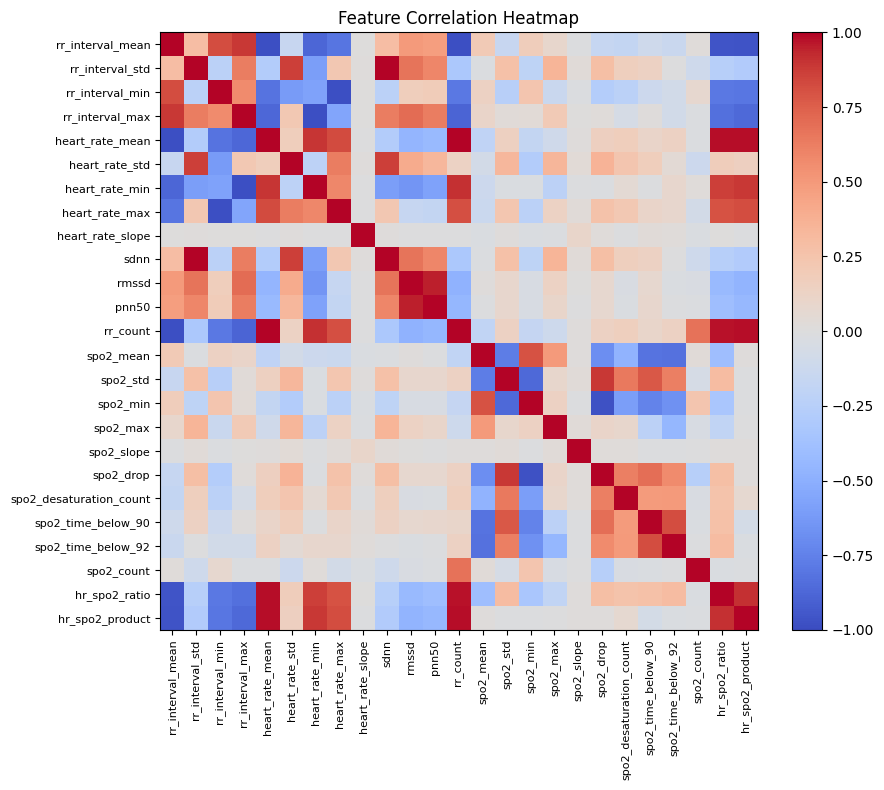

In [15]:
if eda_feature_cols:
    corr = features_df[eda_feature_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=8)
    plt.yticks(range(len(corr.columns)), corr.columns, fontsize=8)
    plt.title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()


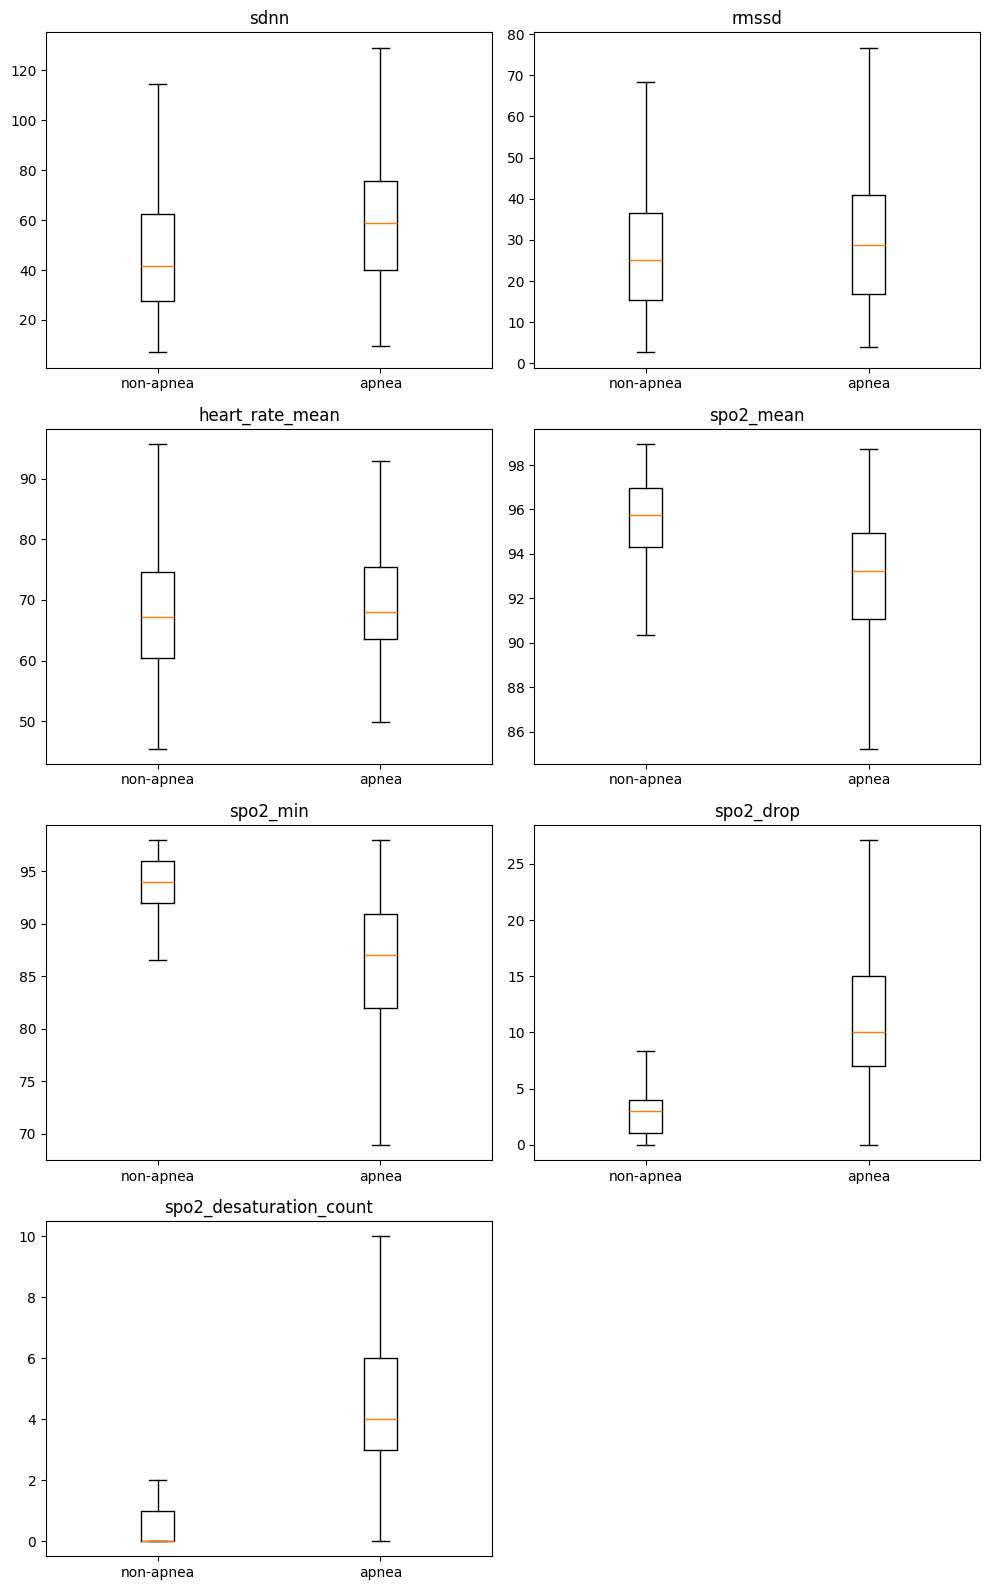

In [16]:
if key_features:
    n_cols = 2
    n_rows = math.ceil(len(key_features) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
    axes = np.asarray(axes).ravel()

    for ax, feature in zip(axes, key_features):
        data = [
            features_df.loc[features_df["label"] == 0, feature].dropna(),
            features_df.loc[features_df["label"] == 1, feature].dropna(),
        ]
        ax.boxplot(data, labels=["non-apnea", "apnea"], showfliers=False)
        ax.set_title(feature)

    for ax in axes[len(key_features):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


## 12. Train/Validation/Test Split


In [17]:
candidate_features = [
    # interval / HR features
    "rr_interval_mean",
    "rr_interval_std",
    "rr_interval_min",
    "rr_interval_max",
    "heart_rate_mean",
    "heart_rate_std",
    "heart_rate_min",
    "heart_rate_max",
    "heart_rate_slope",

    # HRV / PRV-like features
    "sdnn",
    "rmssd",
    "pnn50",

    # SpO2 features
    "spo2_mean",
    "spo2_std",
    "spo2_min",
    "spo2_max",
    "spo2_slope",
    "spo2_drop",
    "spo2_desaturation_count",
    "spo2_time_below_90",
    "spo2_time_below_92",

    # combined features
    "hr_spo2_ratio",
    "hr_spo2_product",
]

exclude_cols = [
    "record_id",
    "minute_index",
    "label",
]

numeric_non_leakage_features = [
    col for col in features_df.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(features_df[col])
]

feature_cols = [col for col in candidate_features if col in features_df.columns]
if not feature_cols:
    feature_cols = numeric_non_leakage_features

print("Final feature columns:")
for col in feature_cols:
    print(" -", col)


Final feature columns:
 - rr_interval_mean
 - rr_interval_std
 - rr_interval_min
 - rr_interval_max
 - heart_rate_mean
 - heart_rate_std
 - heart_rate_min
 - heart_rate_max
 - heart_rate_slope
 - sdnn
 - rmssd
 - pnn50
 - spo2_mean
 - spo2_std
 - spo2_min
 - spo2_max
 - spo2_slope
 - spo2_drop
 - spo2_desaturation_count
 - spo2_time_below_90
 - spo2_time_below_92
 - hr_spo2_ratio
 - hr_spo2_product


In [18]:
y_all = features_df["label"].astype(int)
groups = features_df["record_id"]

gss_train_temp = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=RANDOM_STATE)
train_idx, temp_idx = next(gss_train_temp.split(features_df, y_all, groups))

temp_df = features_df.iloc[temp_idx].reset_index(drop=True)
temp_y = temp_df["label"].astype(int)
temp_groups = temp_df["record_id"]

gss_val_test = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=RANDOM_STATE)
val_rel_idx, test_rel_idx = next(gss_val_test.split(temp_df, temp_y, temp_groups))

train_df = features_df.iloc[train_idx].reset_index(drop=True)
val_df = temp_df.iloc[val_rel_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_rel_idx].reset_index(drop=True)

X_train = train_df[feature_cols]
y_train = train_df["label"].astype(int)
X_val = val_df[feature_cols]
y_val = val_df["label"].astype(int)
X_test = test_df[feature_cols]
y_test = test_df["label"].astype(int)

print("Train shape:", X_train.shape, "records:", train_df["record_id"].nunique())
print("Validation shape:", X_val.shape, "records:", val_df["record_id"].nunique())
print("Test shape:", X_test.shape, "records:", test_df["record_id"].nunique())
print("\nTrain labels:")
print(y_train.value_counts().sort_index())
print("\nValidation labels:")
print(y_val.value_counts().sort_index())
print("\nTest labels:")
print(y_test.value_counts().sort_index())

overlap_train_val = set(train_df["record_id"]) & set(val_df["record_id"])
overlap_train_test = set(train_df["record_id"]) & set(test_df["record_id"])
overlap_val_test = set(val_df["record_id"]) & set(test_df["record_id"])
print("\nRecord overlap train/val:", overlap_train_val)
print("Record overlap train/test:", overlap_train_test)
print("Record overlap val/test:", overlap_val_test)


Train shape: (23916, 23) records: 58
Validation shape: (4705, 23) records: 12
Test shape: (5382, 23) records: 13

Train labels:
label
0    17891
1     6025
Name: count, dtype: int64

Validation labels:
label
0    3635
1    1070
Name: count, dtype: int64

Test labels:
label
0    4631
1     751
Name: count, dtype: int64

Record overlap train/val: set()
Record overlap train/test: set()
Record overlap val/test: set()


## 13. Model Training


In [19]:
def scaled_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])


def tree_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model),
    ])


models = {
    "dummy_most_frequent": tree_pipeline(
        DummyClassifier(strategy="most_frequent")
    ),
    "logistic_regression_balanced": scaled_pipeline(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    ),
    "random_forest_balanced": tree_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    ),
    "gradient_boosting": tree_pipeline(
        GradientBoostingClassifier(random_state=RANDOM_STATE)
    ),
    "hist_gradient_boosting": tree_pipeline(
        HistGradientBoostingClassifier(random_state=RANDOM_STATE)
    ),
    "mlp": scaled_pipeline(
        MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            max_iter=100,
            random_state=RANDOM_STATE,
            early_stopping=True,
        )
    ),
}

if HAS_XGBOOST:
    models["xgboost"] = tree_pipeline(
        xgb.XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    )

if HAS_LIGHTGBM:
    models["lightgbm"] = tree_pipeline(
        lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    )

trained_models = {}
training_errors = []

for model_name, model in models.items():
    print(f"Training {model_name}...")
    try:
        model.fit(X_train, y_train)
        trained_models[model_name] = model
        print(f"  done")
    except Exception as exc:
        training_errors.append({"model_name": model_name, "error": str(exc)})
        print(f"  failed: {exc}")

if training_errors:
    display(pd.DataFrame(training_errors))

if not trained_models:
    raise RuntimeError("No models trained successfully.")


Training dummy_most_frequent...
  done
Training logistic_regression_balanced...
  done
Training random_forest_balanced...
  done
Training gradient_boosting...
  done
Training hist_gradient_boosting...
  done
Training mlp...
  done
Training xgboost...
  done
Training lightgbm...
  done


## 14. Model Evaluation


In [20]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan


def get_positive_scores(model, X):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if proba.shape[1] == 2:
            return proba[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None


def safe_roc_auc(y_true, scores):
    if scores is None or len(np.unique(y_true)) < 2:
        return np.nan
    try:
        return float(roc_auc_score(y_true, scores))
    except Exception:
        return np.nan


def evaluate_model(model, X, y, prefix):
    y_pred = model.predict(X)
    scores = get_positive_scores(model, X)

    return {
        f"{prefix}_accuracy": float(accuracy_score(y, y_pred)),
        f"{prefix}_precision": float(precision_score(y, y_pred, zero_division=0)),
        f"{prefix}_recall": float(recall_score(y, y_pred, zero_division=0)),
        f"{prefix}_f1": float(f1_score(y, y_pred, zero_division=0)),
        f"{prefix}_roc_auc": safe_roc_auc(y, scores),
        f"{prefix}_specificity": float(specificity_score(y, y_pred)),
    }


rows = []
for model_name, model in trained_models.items():
    row = {"model_name": model_name}
    row.update(evaluate_model(model, X_val, y_val, "validation"))
    row.update(evaluate_model(model, X_test, y_test, "test"))
    rows.append(row)

results_df = pd.DataFrame(rows)
sort_cols = ["test_recall", "test_f1", "test_roc_auc"]
results_df = results_df.sort_values(sort_cols, ascending=False, na_position="last").reset_index(drop=True)
display(results_df)

results_path = REPORTS_DIR / "model_comparison.csv"
results_df.to_csv(results_path, index=False)
print("Saved:", results_path)


,model_name,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_specificity,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_specificity
0,lightgbm,0.872476,0.692939,0.788785,0.737762,0.915755,0.897111,0.922148,0.670782,0.868176,0.756820,0.953997,0.930900
1,logistic_regression_balanced,0.870776,0.675266,0.831776,0.745394,0.925361,0.882256,0.918060,0.657201,0.862850,0.746114,0.954523,0.927014
2,gradient_boosting,0.892667,0.781655,0.732710,0.756392,0.928819,0.939752,0.937755,0.768734,0.792277,0.780328,0.955867,0.961347
3,hist_gradient_boosting,0.888842,0.766829,0.734579,0.750358,0.918017,0.934250,0.936826,0.767230,0.785619,0.776316,0.955346,0.961347
4,xgboost,0.890967,0.773845,0.735514,0.754193,0.922787,0.936726,0.937384,0.776000,0.774967,0.775483,0.959186,0.963723
5,mlp,0.880978,0.760204,0.696262,0.726829,0.916509,0.935351,0.933482,0.760265,0.764314,0.762284,0.954678,0.960916
6,random_forest_balanced,0.892880,0.820862,0.676636,0.741803,0.919090,0.956534,0.934968,0.778086,0.747004,0.762228,0.951555,0.965450
7,dummy_most_frequent,0.772582,0.000000,0.000000,0.000000,0.500000,1.000000,0.860461,0.000000,0.000000,0.000000,0.500000,1.000000


Saved: reports\model_comparison.csv


In [21]:
for model_name in results_df["model_name"]:
    print("=" * 80)
    print(model_name)
    model = trained_models[model_name]
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=["non-apnea", "apnea"], zero_division=0))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred, labels=[0, 1]))


lightgbm
              precision    recall  f1-score   support

   non-apnea       0.98      0.93      0.95      4631
       apnea       0.67      0.87      0.76       751

    accuracy                           0.92      5382
   macro avg       0.82      0.90      0.86      5382
weighted avg       0.93      0.92      0.93      5382

Confusion matrix:
[[4311  320]
 [  99  652]]
logistic_regression_balanced
              precision    recall  f1-score   support

   non-apnea       0.98      0.93      0.95      4631
       apnea       0.66      0.86      0.75       751

    accuracy                           0.92      5382
   macro avg       0.82      0.89      0.85      5382
weighted avg       0.93      0.92      0.92      5382

Confusion matrix:
[[4293  338]
 [ 103  648]]
gradient_boosting
              precision    recall  f1-score   support

   non-apnea       0.97      0.96      0.96      4631
       apnea       0.77      0.79      0.78       751

    accuracy                        

## 15. Model Comparison


In [22]:
best_model_name = results_df.iloc[0]["model_name"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
print("Selection priority: test recall, then test F1, then test ROC AUC.")
display(results_df)


Best model: lightgbm
Selection priority: test recall, then test F1, then test ROC AUC.


,model_name,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_specificity,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_specificity
0,lightgbm,0.872476,0.692939,0.788785,0.737762,0.915755,0.897111,0.922148,0.670782,0.868176,0.756820,0.953997,0.930900
1,logistic_regression_balanced,0.870776,0.675266,0.831776,0.745394,0.925361,0.882256,0.918060,0.657201,0.862850,0.746114,0.954523,0.927014
2,gradient_boosting,0.892667,0.781655,0.732710,0.756392,0.928819,0.939752,0.937755,0.768734,0.792277,0.780328,0.955867,0.961347
3,hist_gradient_boosting,0.888842,0.766829,0.734579,0.750358,0.918017,0.934250,0.936826,0.767230,0.785619,0.776316,0.955346,0.961347
4,xgboost,0.890967,0.773845,0.735514,0.754193,0.922787,0.936726,0.937384,0.776000,0.774967,0.775483,0.959186,0.963723
5,mlp,0.880978,0.760204,0.696262,0.726829,0.916509,0.935351,0.933482,0.760265,0.764314,0.762284,0.954678,0.960916
6,random_forest_balanced,0.892880,0.820862,0.676636,0.741803,0.919090,0.956534,0.934968,0.778086,0.747004,0.762228,0.951555,0.965450
7,dummy_most_frequent,0.772582,0.000000,0.000000,0.000000,0.500000,1.000000,0.860461,0.000000,0.000000,0.000000,0.500000,1.000000


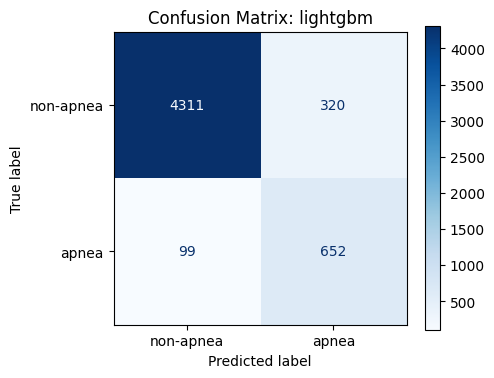

In [23]:
y_test_pred = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    labels=[0, 1],
    display_labels=["non-apnea", "apnea"],
    cmap="Blues",
    ax=ax,
)
ax.set_title(f"Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.show()


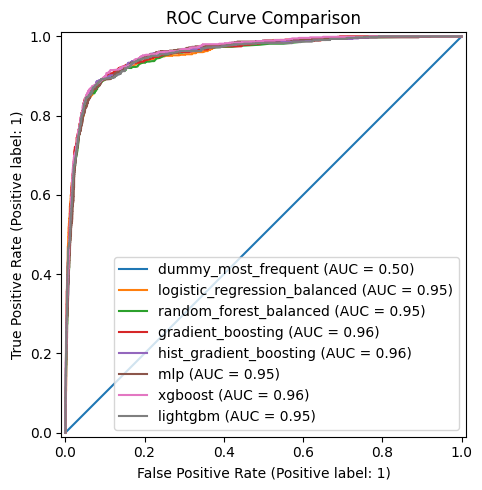

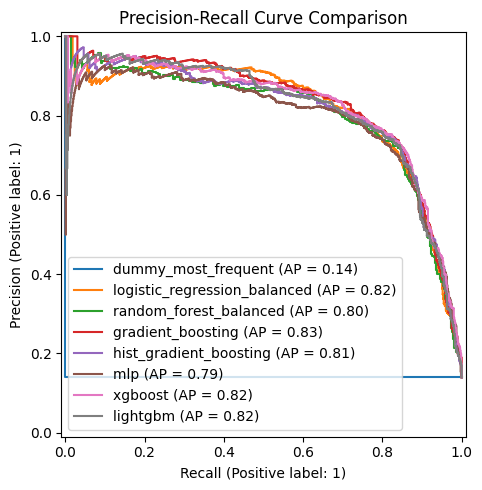

In [24]:
if len(np.unique(y_test)) == 2:
    fig, ax = plt.subplots(figsize=(7, 5))
    for model_name, model in trained_models.items():
        scores = get_positive_scores(model, X_test)
        if scores is not None:
            RocCurveDisplay.from_predictions(y_test, scores, name=model_name, ax=ax)
    ax.set_title("ROC Curve Comparison")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    for model_name, model in trained_models.items():
        scores = get_positive_scores(model, X_test)
        if scores is not None:
            PrecisionRecallDisplay.from_predictions(y_test, scores, name=model_name, ax=ax)
    ax.set_title("Precision-Recall Curve Comparison")
    plt.tight_layout()
    plt.show()
else:
    print("ROC and precision-recall curves skipped because y_test has a single class.")


## 16. Feature Importance


Feature importance source: lightgbm


,importance
spo2_std,755.0
rmssd,710.0
spo2_slope,647.0
spo2_mean,626.0
heart_rate_slope,600.0
heart_rate_std,478.0
pnn50,474.0
rr_interval_std,453.0
hr_spo2_product,453.0
spo2_max,408.0


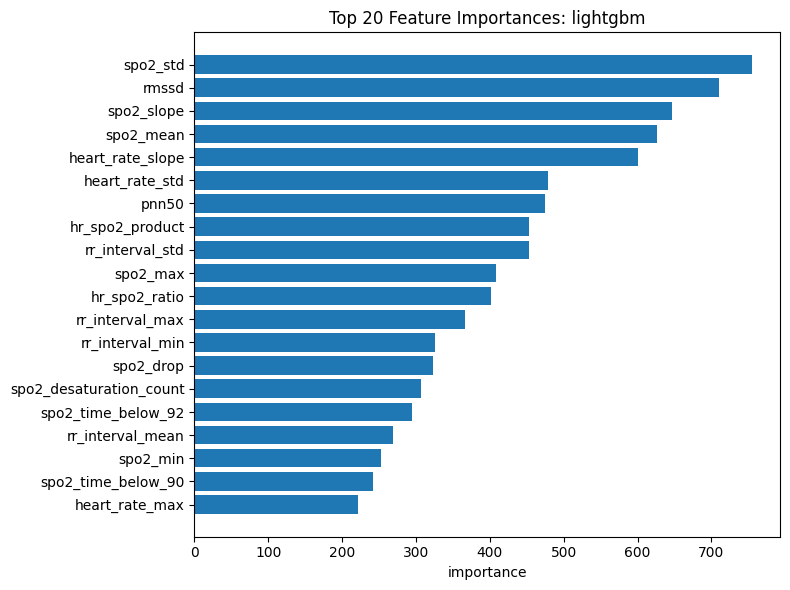

In [25]:
def model_importance_series(pipeline, feature_cols):
    model = pipeline.named_steps.get("model", pipeline)

    if hasattr(model, "feature_importances_"):
        values = np.asarray(model.feature_importances_, dtype=float)
        return pd.Series(values, index=feature_cols).sort_values(ascending=False)

    if hasattr(model, "coef_"):
        values = np.abs(np.asarray(model.coef_).ravel())
        return pd.Series(values, index=feature_cols).sort_values(ascending=False)

    return None


importance_model_name = None
importance = model_importance_series(best_model, feature_cols)

if importance is None:
    for candidate_name in results_df["model_name"]:
        candidate_importance = model_importance_series(trained_models[candidate_name], feature_cols)
        if candidate_importance is not None:
            importance_model_name = candidate_name
            importance = candidate_importance
            break
else:
    importance_model_name = best_model_name

if importance is not None:
    print("Feature importance source:", importance_model_name)
    display(importance.head(20).to_frame("importance"))

    top20 = importance.head(20).sort_values()
    plt.figure(figsize=(8, 6))
    plt.barh(top20.index, top20.values)
    plt.title(f"Top 20 Feature Importances: {importance_model_name}")
    plt.xlabel("importance")
    plt.tight_layout()
    plt.show()
else:
    print("No feature importance or coefficient vector is available for the trained models.")


## 17. Export Best Model


In [26]:
model_path = MODELS_DIR / "apnea_detection_model.joblib"
feature_cols_path = MODELS_DIR / "apnea_detection_feature_columns.joblib"
metadata_path = MODELS_DIR / "apnea_detection_metadata.json"

joblib.dump(best_model, model_path)
joblib.dump(feature_cols, feature_cols_path)

metadata = {
    "dataset": "Mendeley APNEA HRV+SPO2 / HuGCDN2014-OXI",
    "task": "1-minute apnea vs non-apnea classification",
    "target": {
        "0": "non-apnea",
        "1": "apnea",
    },
    "feature_cols": feature_cols,
    "best_model_name": best_model_name,
    "split_strategy": "Group split by record_id",
    "metrics": results_df.iloc[0].replace({np.nan: None}).to_dict(),
    "notes": [
        "RR folder contains ECG-derived R-R intervals, not respiratory rate.",
        "SAT folder contains SpO2 / oxygen saturation values.",
        "LABELS folder contains apnea/non-apnea labels per minute.",
        "For MAX30102 deployment, ECG-derived RR intervals should be approximated using PPG-derived pulse intervals.",
        "This model is for research/prototype use and is not a clinical diagnostic tool.",
    ],
}

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model:", model_path)
print("Saved feature columns:", feature_cols_path)
print("Saved metadata:", metadata_path)


Saved model: models\apnea_detection_model.joblib
Saved feature columns: models\apnea_detection_feature_columns.joblib
Saved metadata: models\apnea_detection_metadata.json


## 18. Sample Inference Function


In [27]:
def predict_apnea(sample_dict, model=best_model, feature_cols=feature_cols):
    sample_df = pd.DataFrame([sample_dict])

    missing_cols = [col for col in feature_cols if col not in sample_df.columns]
    if missing_cols:
        raise ValueError(f"Missing required feature columns: {missing_cols}")

    sample_df = sample_df[feature_cols]
    pred = int(model.predict(sample_df)[0])

    result = {
        "prediction": pred,
        "label": "apnea" if pred == 1 else "non-apnea",
    }

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(sample_df)[0]
        result["apnea_probability"] = float(proba[1])

    return result


sample = {
    col: float(features_df[col].median())
    for col in feature_cols
}

predict_apnea(sample)


{'prediction': 0,
 'label': 'non-apnea',
 'apnea_probability': 0.3734222153866868}

## 19. MAX30102 Cloud Compatibility Notes

The model is trained from ECG-derived R-R interval features and SpO2 features.

For deployment, the MAX30102 pipeline should generate similar 1-minute features from PPG-derived pulse intervals and SpO2 readings. The exported `feature_cols` list defines the exact column names and order expected by the model.

ECG-derived R-R intervals and PPG-derived pulse intervals are not identical, so real-world validation and calibration are required before using this in a deployed product.


## 20. Limitations

1. This dataset uses ECG-derived R-R intervals, while MAX30102 provides PPG-derived pulse intervals.
2. The dataset labels are per minute, so the model predicts per-minute apnea risk.
3. The model is not a clinical diagnostic tool.
4. Record-level splitting is required to reduce leakage.
5. External validation with real MAX30102 data is required.
6. RR in this dataset means R-R interval, not respiratory rate.
